  0%|                        |

Solving NLP with Adam (36 optimization variables) ...


100%|████████████████████████|
    f =   0.000810, f* =  0.000203, |grad f| =  940.100972, iter = 1200


Solving NLP with L-BFGS (36 optimization variables) ...
L-BFGS-B done in 249 iterations.


  0%|                        |

Solving NLP with Adam (11 optimization variables) ...


100%|████████████████████████|
    f =   0.000524, f* =  0.000524, |grad f| =  0.000211, iter = 1500
  0%|                        |

Solving NLP with Adam (47 optimization variables) ...


100%|████████████████████████|
    f =   0.013298, f* =  0.000089, |grad f| =  4827.439874, iter = 2000


Chosen cycle: 0
Selection note: index mode -> using cycle 0


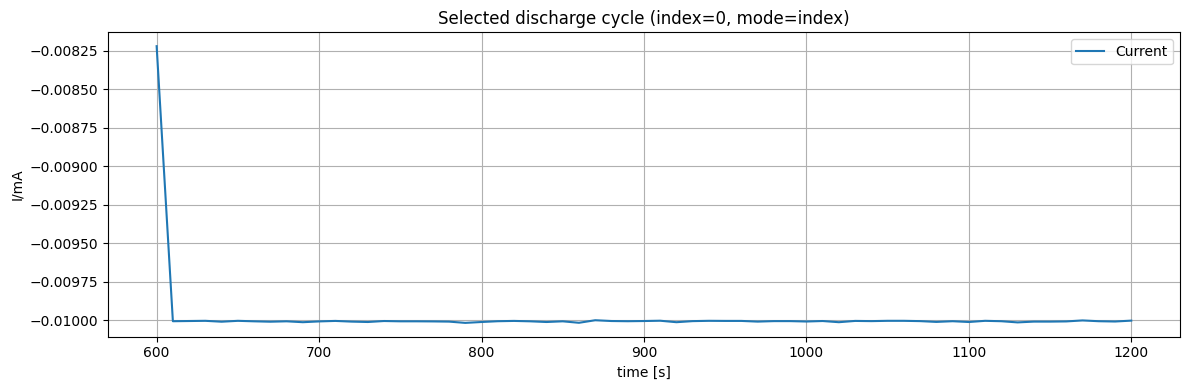

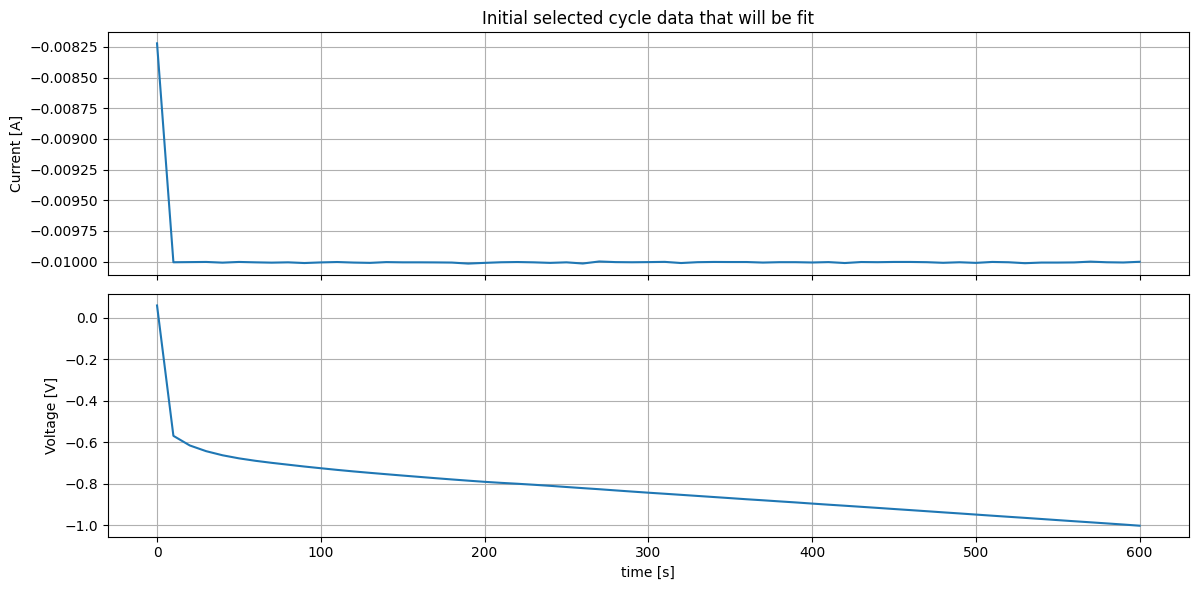

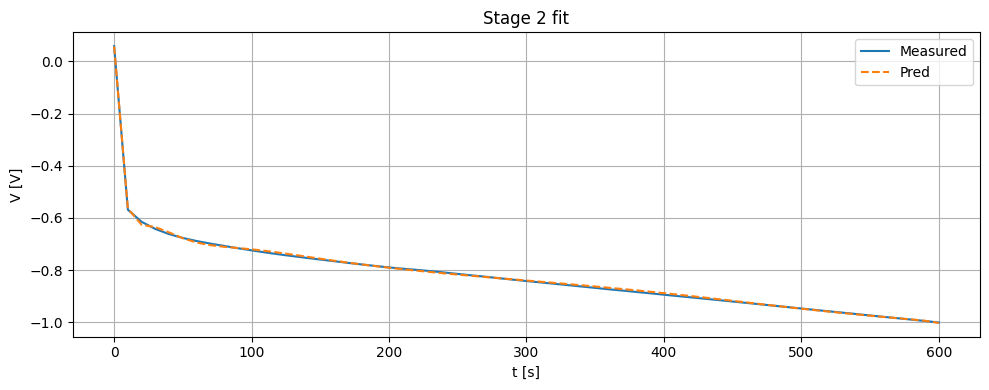

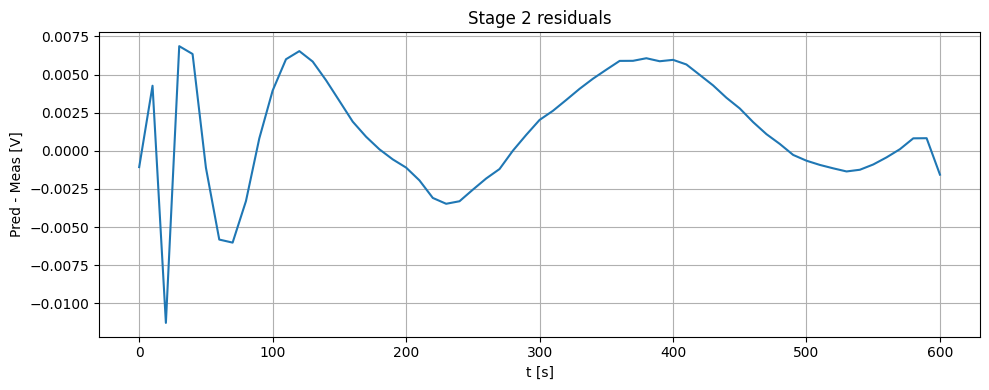

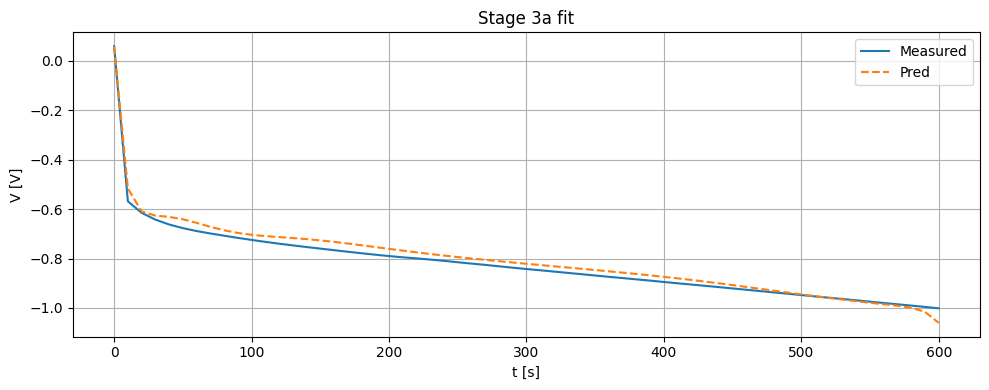

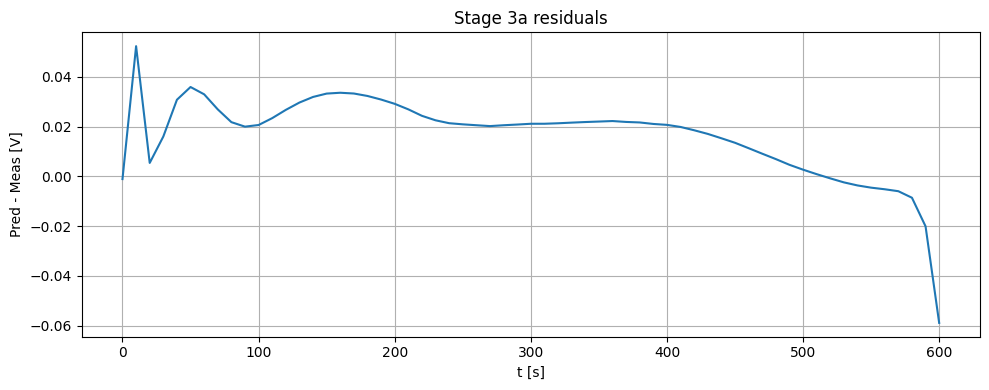

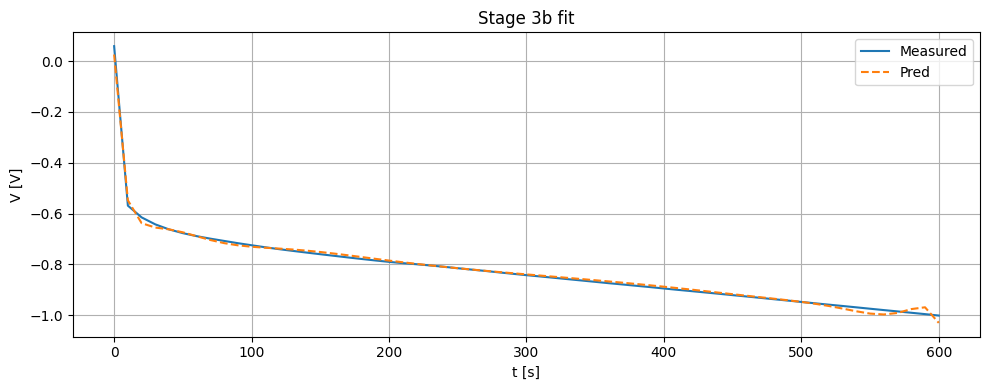

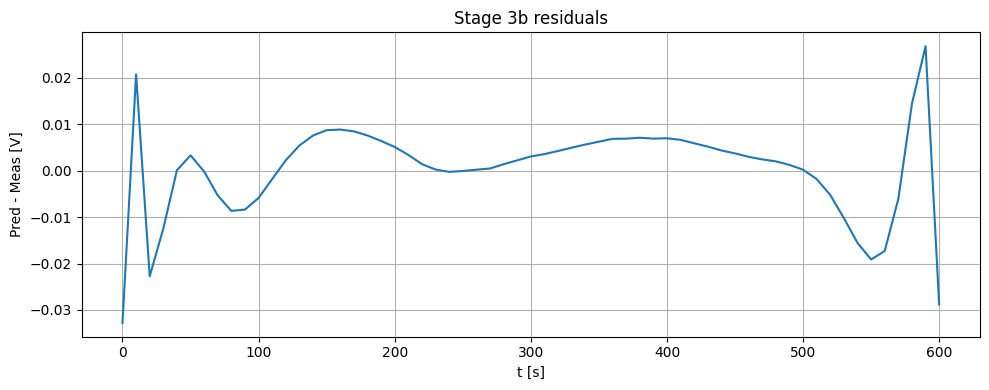

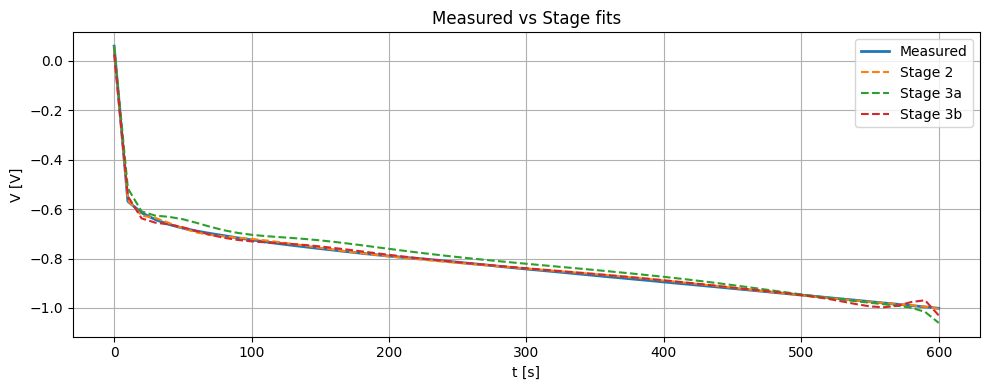

,stage,rmse,mae,p95,p99,max_abs,R0_hat,thetaZ_l2_norm,thetaZ_max_abs
0,stage2,0.003858,0.003061,0.006346,0.008625,0.011275,0.049312,0.835699,0.833383
1,stage3a,0.023296,0.020242,0.033652,0.054990,0.058895,NaN,NaN,NaN
2,stage3b,0.010121,0.007143,0.022750,0.030413,0.032804,0.048772,0.845947,0.844201


Stage 2 RMSE: 0.003858349048109165
Stage 3a RMSE: 0.023295760932891974
Stage 3b RMSE: 0.010121478768674242


C:\Users\onyer\OneDrive\Desktop\Research work\1. Projects\battery-degradation-spme-sysid\src\battery_deg_spme\visualization\nonlinearity_plots.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


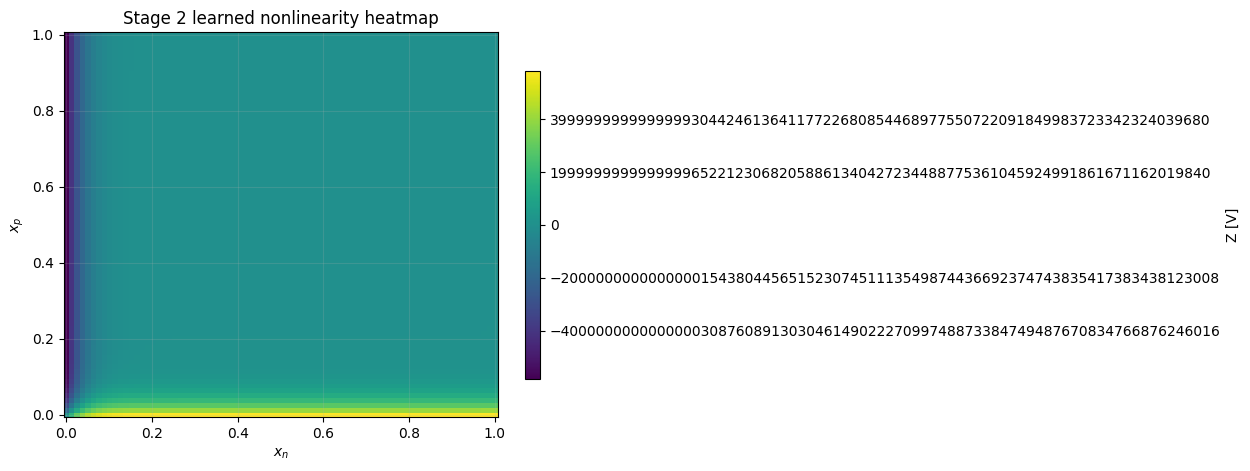

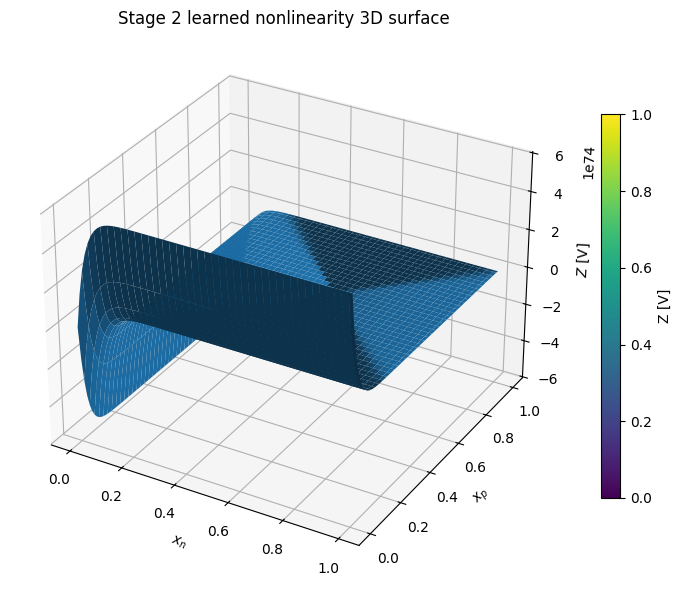

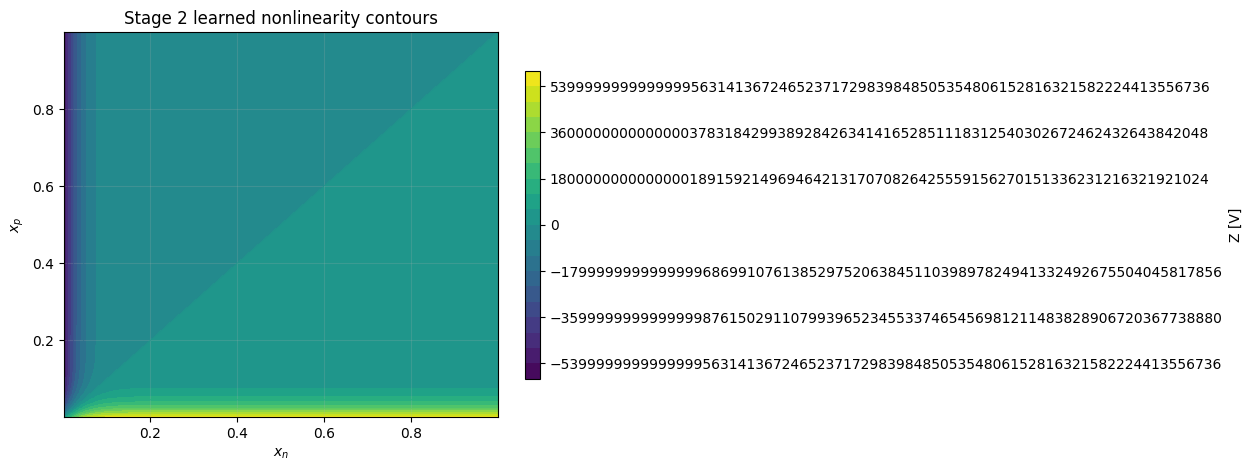

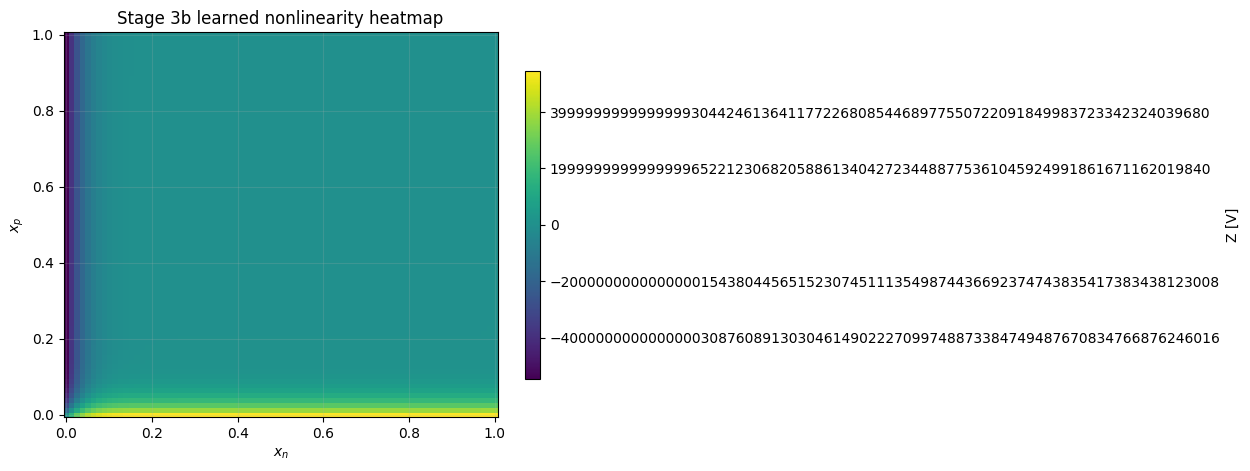

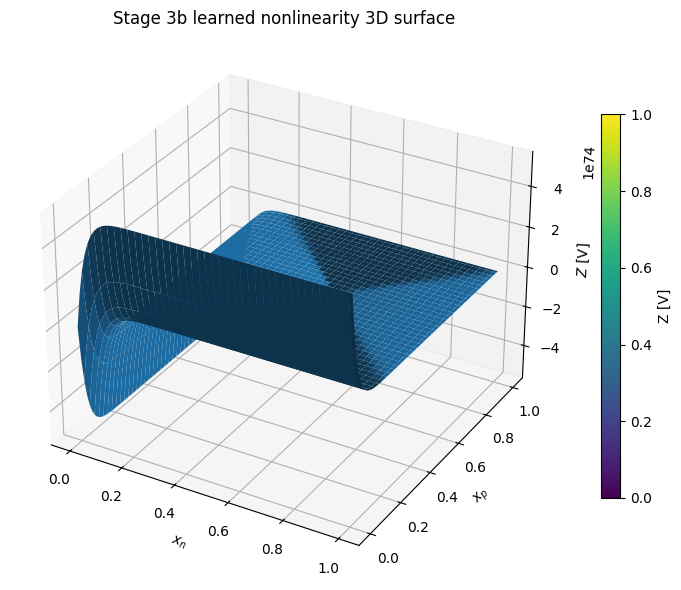

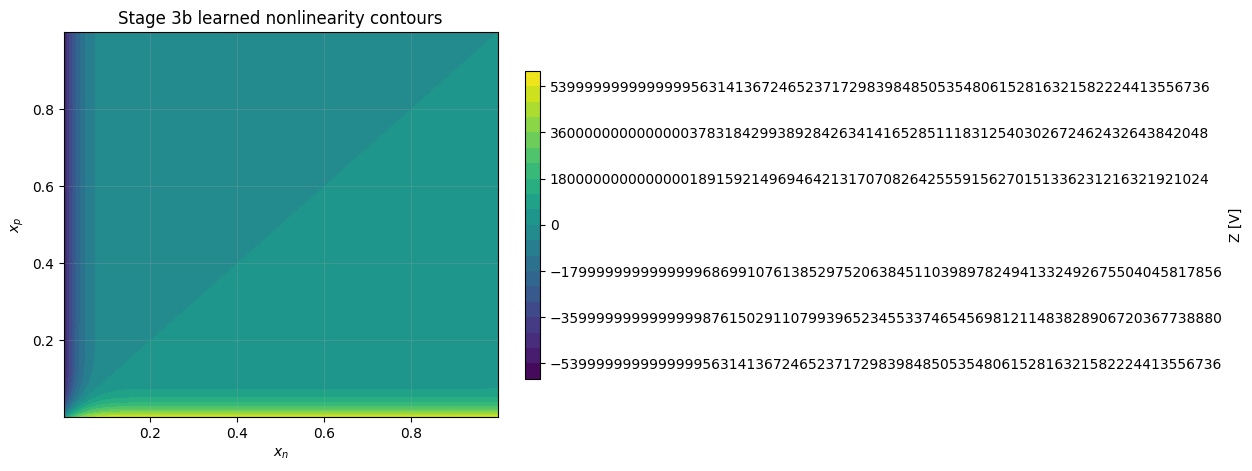

In [1]:
# Cell 0 — Imports
from __future__ import annotations

import numpy as np
from IPython.display import display

from battery_deg_spme.analysis.nonlinearity import evaluate_surface_on_grid
from battery_deg_spme.analysis.summaries import make_stage_summary_table
from battery_deg_spme.config.settings import get_default_settings
from battery_deg_spme.fitting.cycle_pipeline import run_single_cycle_pipeline
from battery_deg_spme.visualization.cycle_plots import (
    plot_cycle_voltage_current,
    plot_selected_cycle,
)
from battery_deg_spme.visualization.fit_plots import (
    plot_residuals,
    plot_stage_fit_comparison,
    plot_voltage,
)
from battery_deg_spme.visualization.nonlinearity_plots import (
    plot_nonlinearity_heatmap,
    plot_nonlinearity_surface,
    plot_surrogate_contours,
)


# Cell 1 — Small helper for learned nonlinearity surface
def _build_learned_surface_fn(
    thetaZ_hat: np.ndarray,
    zhat_from_thetaZ,
    cfg,
    state_template: np.ndarray,
):
    thetaZ_hat = np.asarray(thetaZ_hat, dtype=np.float64).reshape(-1)
    state_template = np.asarray(state_template, dtype=np.float64).reshape(-1)

    def learned_surface_fn(xn: float, xp: float) -> float:
        x = state_template.copy()
        x[3] = float(xn) * float(cfg.csn_max)
        x[7] = float(xp) * float(cfg.csp_max)
        return float(zhat_from_thetaZ(x, thetaZ_hat))

    return learned_surface_fn


# Cell 2 — Settings
settings = get_default_settings()

# Optional quick-test overrides
settings.cycle.cycle_mode = "index"
settings.cycle.cycle_index = 0
# settings.surrogate.poly_deg = 10


# Cell 3 — Run single-cycle pipeline
result = run_single_cycle_pipeline(settings)

cfg = result["cfg"]
prep = result["prep"]
proxy = result["proxy"]
stage2 = result["stage2"]
stage3a = result["stage3a"]
stage3b = result["stage3b"]

print("Chosen cycle:", result["chosen_cycle_idx"])
print("Selection note:", result["selection_note"])


# Cell 4 — Plot the initial data that will be fit
plot_selected_cycle(
    cycle_df=result["cycle_df"],
    i_col=settings.data.i_col,
    chosen=result["chosen_cycle_idx"],
    mode=settings.cycle.cycle_mode,
    show=True,
)

plot_cycle_voltage_current(
    t=prep["t"],
    u=prep["u"],
    y=prep["y"],
    title="Initial selected cycle data that will be fit",
    show=True,
)


# Cell 5 — Stage 2 / 3a / 3b voltage fits
plot_voltage(
    prep["t"],
    prep["y"],
    stage2["yhat"],
    title="Stage 2 fit",
    show=True,
)

plot_residuals(
    prep["t"],
    prep["y"],
    stage2["yhat"],
    title="Stage 2 residuals",
    show=True,
)

if stage3a is not None:
    plot_voltage(
        prep["t"],
        prep["y"],
        stage3a["yhat"],
        title="Stage 3a fit",
        show=True,
    )

    plot_residuals(
        prep["t"],
        prep["y"],
        stage3a["yhat"],
        title="Stage 3a residuals",
        show=True,
    )

if stage3b is not None:
    plot_voltage(
        prep["t"],
        prep["y"],
        stage3b["yhat"],
        title="Stage 3b fit",
        show=True,
    )

    plot_residuals(
        prep["t"],
        prep["y"],
        stage3b["yhat"],
        title="Stage 3b residuals",
        show=True,
    )


# Cell 6 — Combined stage comparison
stage_curves = {"Stage 2": stage2["yhat"]}
if stage3a is not None:
    stage_curves["Stage 3a"] = stage3a["yhat"]
if stage3b is not None:
    stage_curves["Stage 3b"] = stage3b["yhat"]

plot_stage_fit_comparison(
    prep["t"],
    prep["y"],
    stage_curves=stage_curves,
    title="Measured vs Stage fits",
    show=True,
)


# Cell 7 — Stage summary table
stage_results = {"stage2": stage2}
if stage3a is not None:
    stage_results["stage3a"] = stage3a
if stage3b is not None:
    stage_results["stage3b"] = stage3b

stage_summary_df = make_stage_summary_table(stage_results)
display(stage_summary_df)

print("Stage 2 RMSE:", stage2["metrics"]["rmse"])
if stage3a is not None:
    print("Stage 3a RMSE:", stage3a["metrics"]["rmse"])
if stage3b is not None:
    print("Stage 3b RMSE:", stage3b["metrics"]["rmse"])


# Cell 8 — Learned Stage 2 nonlinearity
zhat_from_thetaZ = stage2["zhat_from_thetaZ"]

stage2_state_template = (
    np.asarray(stage2["xhat"][0], dtype=np.float64)
    if stage2.get("xhat", None) is not None
    else np.asarray(proxy["X_proxy"][0], dtype=np.float64)
)

stage2_surface_fn = _build_learned_surface_fn(
    thetaZ_hat=stage2["thetaZ_hat"],
    zhat_from_thetaZ=zhat_from_thetaZ,
    cfg=cfg,
    state_template=stage2_state_template,
)

stage2_surface = evaluate_surface_on_grid(
    surface_fn=stage2_surface_fn,
    n_per_axis=settings.surrogate.nonlinearity_grid_n,
    guard=settings.surrogate.nonlinearity_guard,
)

plot_nonlinearity_heatmap(
    stage2_surface.XN,
    stage2_surface.XP,
    stage2_surface.Z,
    title="Stage 2 learned nonlinearity heatmap",
    show=True,
)

plot_nonlinearity_surface(
    stage2_surface.XN,
    stage2_surface.XP,
    stage2_surface.Z,
    title="Stage 2 learned nonlinearity 3D surface",
    show=True,
)

plot_surrogate_contours(
    stage2_surface.xn_grid,
    stage2_surface.xp_grid,
    stage2_surface.Z,
    title="Stage 2 learned nonlinearity contours",
    show=True,
)


# Cell 9 — Learned Stage 3b nonlinearity
if stage3b is not None:
    stage3b_state_template = np.asarray(stage3b["xhat"][0], dtype=np.float64)

    stage3b_surface_fn = _build_learned_surface_fn(
        thetaZ_hat=stage3b["thetaZ_hat"],
        zhat_from_thetaZ=zhat_from_thetaZ,
        cfg=cfg,
        state_template=stage3b_state_template,
    )

    stage3b_surface = evaluate_surface_on_grid(
        surface_fn=stage3b_surface_fn,
        n_per_axis=settings.surrogate.nonlinearity_grid_n,
        guard=settings.surrogate.nonlinearity_guard,
    )

    plot_nonlinearity_heatmap(
        stage3b_surface.XN,
        stage3b_surface.XP,
        stage3b_surface.Z,
        title="Stage 3b learned nonlinearity heatmap",
        show=True,
    )

    plot_nonlinearity_surface(
        stage3b_surface.XN,
        stage3b_surface.XP,
        stage3b_surface.Z,
        title="Stage 3b learned nonlinearity 3D surface",
        show=True,
    )

    plot_surrogate_contours(
        stage3b_surface.xn_grid,
        stage3b_surface.xp_grid,
        stage3b_surface.Z,
        title="Stage 3b learned nonlinearity contours",
        show=True,
    )